# 05 — Preprocessing dan Augmentasi Dataset Citra Awan

Notebook ini menyiapkan pipeline input citra untuk training model klasifikasi
jenis awan menggunakan PyTorch dan Albumentations.

Dataset yang digunakan berasal dari:

```text
dataset/source/
├── train/
├── val/
└── test/

In [15]:
from pathlib import Path, PurePosixPath
import json
import random
import sys

try:
    import albumentations as A
    import cv2
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import torch

    from albumentations.pytorch import ToTensorV2
    from IPython.display import display
    from torch.utils.data import DataLoader, Dataset

except ImportError as exc:
    raise ImportError(
        "Dependency preprocessing belum lengkap.\n"
        "Aktifkan .venv, kemudian jalankan melalui terminal VS Code:\n\n"
        r".\.venv\Scripts\python.exe -m pip install -r requirements.txt"
    ) from exc


pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

cv2.setNumThreads(0)


print(f"Python          : {sys.version.split()[0]}")
print(f"NumPy           : {np.__version__}")
print(f"Pandas          : {pd.__version__}")
print(f"PyTorch         : {torch.__version__}")
print(f"OpenCV          : {cv2.__version__}")
print(f"Albumentations  : {A.__version__}")
print(f"CUDA tersedia   : {torch.cuda.is_available()}")

Python          : 3.11.9
NumPy           : 2.4.6
Pandas          : 3.0.5
PyTorch         : 2.13.0+cpu
OpenCV          : 5.0.0
Albumentations  : 2.0.8
CUDA tersedia   : False


## Menentukan Lokasi Project

Lokasi project ditentukan secara dinamis agar notebook dapat dijalankan dari:

- folder utama `cloud-classification`; atau
- folder `cloud-classification/notebooks`.

Notebook tidak menggunakan path absolut Docker `/app`.

In [16]:
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR


DATASET_DIR = PROJECT_DIR / "dataset"
RAW_DIR = DATASET_DIR / "raw"
SOURCE_DIR = DATASET_DIR / "source"
PROCESSED_DIR = DATASET_DIR / "processed"

MODELS_DIR = PROJECT_DIR / "models"
LOGS_DIR = PROJECT_DIR / "logs"

SOURCE_TRAIN_DIR = SOURCE_DIR / "train"
SOURCE_VAL_DIR = SOURCE_DIR / "val"
SOURCE_TEST_DIR = SOURCE_DIR / "test"


MANIFEST_PATH = (
    PROCESSED_DIR
    / "dataset_split_manifest.csv"
)

SPLIT_SUMMARY_PATH = (
    PROCESSED_DIR
    / "split_summary.json"
)

PREPROCESSING_INDEX_PATH = (
    PROCESSED_DIR
    / "preprocessing_dataset_index.csv"
)

CLASS_MAPPING_PATH = (
    PROCESSED_DIR
    / "class_mapping.json"
)

PREPROCESSING_CONFIG_PATH = (
    PROCESSED_DIR
    / "preprocessing_config.json"
)


path_table = pd.DataFrame({
    "Nama": [
        "PROJECT_DIR",
        "SOURCE_DIR",
        "SOURCE_TRAIN_DIR",
        "SOURCE_VAL_DIR",
        "SOURCE_TEST_DIR",
        "PROCESSED_DIR",
        "MANIFEST_PATH",
    ],
    "Path": [
        PROJECT_DIR,
        SOURCE_DIR,
        SOURCE_TRAIN_DIR,
        SOURCE_VAL_DIR,
        SOURCE_TEST_DIR,
        PROCESSED_DIR,
        MANIFEST_PATH,
    ],
})

path_table["Ada"] = (
    path_table["Path"].map(Path.exists)
)

display(path_table)

,Nama,Path,Ada
0,PROJECT_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification,True
1,SOURCE_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source,True
2,SOURCE_TRAIN_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\train,True
3,SOURCE_VAL_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\val,True
4,SOURCE_TEST_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\test,True
5,PROCESSED_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\processed,True
6,MANIFEST_PATH,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\processed\dataset_split_manifest.csv,True


## Konfigurasi Preprocessing

Ukuran input ditetapkan menjadi `224 × 224` piksel agar kompatibel dengan
arsitektur CNN pretrained yang umum digunakan melalui torchvision atau timm.

Normalisasi menggunakan statistik ImageNet:

- mean: `(0.485, 0.456, 0.406)`
- standard deviation: `(0.229, 0.224, 0.225)`

Data validation dan test tidak diberi augmentasi karena keduanya harus
menghasilkan evaluasi yang konsisten dan deterministik.

In [17]:
RANDOM_STATE = 42

IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224

BATCH_SIZE = 32

# Nilai 0 paling stabil untuk Jupyter di Windows.
NUM_WORKERS = 0

PIN_MEMORY = torch.cuda.is_available()

SPLIT_ORDER = [
    "train",
    "val",
    "test",
]

EXPECTED_CLASS_COUNT = 7

IMAGENET_MEAN = (
    0.485,
    0.456,
    0.406,
)

IMAGENET_STD = (
    0.229,
    0.224,
    0.225,
)

ALLOWED_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp",
}


configuration_table = pd.DataFrame({
    "Parameter": [
        "Random state",
        "Ukuran input",
        "Batch size",
        "Jumlah worker",
        "Pin memory",
        "Normalisasi",
    ],
    "Nilai": [
        RANDOM_STATE,
        f"{IMAGE_HEIGHT} × {IMAGE_WIDTH}",
        BATCH_SIZE,
        NUM_WORKERS,
        PIN_MEMORY,
        "ImageNet",
    ],
})

display(configuration_table)

,Parameter,Nilai
0,Random state,42
1,Ukuran input,224 × 224
2,Batch size,32
3,Jumlah worker,0
4,Pin memory,False
5,Normalisasi,ImageNet


In [18]:
def set_random_seed(seed):
    """
    Menetapkan seed pada Python, NumPy, dan PyTorch.
    """

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def seed_worker(worker_id):
    """
    Menetapkan seed untuk setiap worker DataLoader.
    Fungsi ini tetap disediakan apabila NUM_WORKERS
    nantinya dinaikkan.
    """

    del worker_id

    worker_seed = (
        torch.initial_seed()
        % (2 ** 32)
    )

    random.seed(worker_seed)
    np.random.seed(worker_seed)


set_random_seed(RANDOM_STATE)

print(
    f"Seed eksperimen ditetapkan: "
    f"{RANDOM_STATE}"
)

Seed eksperimen ditetapkan: 42


## Pemeriksaan Prasyarat

Notebook hanya melakukan pemeriksaan minimum karena audit lengkap telah
dilakukan pada notebook 04.

Notebook dihentikan apabila:

- folder train, validation, atau test tidak tersedia;
- manifest final tidak tersedia;
- folder processed tidak tersedia.

Tidak dilakukan penghitungan ulang hash dan analisis duplikat.

In [19]:
required_directories = [
    PROJECT_DIR,
    DATASET_DIR,
    SOURCE_DIR,
    SOURCE_TRAIN_DIR,
    SOURCE_VAL_DIR,
    SOURCE_TEST_DIR,
    PROCESSED_DIR,
]

required_files = [
    MANIFEST_PATH,
]


missing_directories = [
    path
    for path in required_directories
    if not path.is_dir()
]

missing_files = [
    path
    for path in required_files
    if not path.is_file()
]


if missing_directories:
    formatted_paths = "\n".join(
        f"- {path}"
        for path in missing_directories
    )

    raise FileNotFoundError(
        "Folder prasyarat belum tersedia:\n"
        f"{formatted_paths}"
    )


if missing_files:
    formatted_paths = "\n".join(
        f"- {path}"
        for path in missing_files
    )

    raise FileNotFoundError(
        "Metadata hasil notebook 04 "
        "belum tersedia:\n"
        f"{formatted_paths}"
    )


assert RAW_DIR.resolve() != SOURCE_DIR.resolve(), (
    "Folder raw dan source tidak boleh sama."
)

assert MANIFEST_PATH.parent.resolve() == (
    PROCESSED_DIR.resolve()
), (
    "Manifest harus berada di dataset/processed."
)


print("Seluruh prasyarat preprocessing tersedia.")
print("Dataset raw dan source hanya akan dibaca.")

Seluruh prasyarat preprocessing tersedia.
Dataset raw dan source hanya akan dibaca.


In [20]:
manifest_df = pd.read_csv(
    MANIFEST_PATH
)


required_manifest_columns = {
    "target_split",
    "class_name",
    "target_relative_path",
    "filename",
    "width",
    "height",
    "sha256",
}


missing_columns = (
    required_manifest_columns
    - set(manifest_df.columns)
)

if missing_columns:
    raise ValueError(
        "Kolom manifest belum lengkap: "
        f"{sorted(missing_columns)}"
    )


assert not manifest_df.empty, (
    "Manifest dataset tidak boleh kosong."
)

assert (
    manifest_df[
        list(required_manifest_columns)
    ]
    .notna()
    .all()
    .all()
), (
    "Manifest masih memiliki nilai kosong "
    "pada kolom utama."
)


invalid_splits = (
    set(manifest_df["target_split"].unique())
    - set(SPLIT_ORDER)
)

assert not invalid_splits, (
    "Manifest memiliki nama split tidak valid: "
    f"{sorted(invalid_splits)}"
)


print(
    f"Jumlah baris manifest : "
    f"{len(manifest_df):,}"
)

print(
    f"Jumlah kelas          : "
    f"{manifest_df['class_name'].nunique()}"
)

print(
    "Split tersedia       : "
    f"{sorted(manifest_df['target_split'].unique())}"
)

display(manifest_df.head())

Jumlah baris manifest : 18,843
Jumlah kelas          : 7
Split tersedia       : ['test', 'train', 'val']


,raw_split,target_split,class_name,source_path,source_relative_path,target_path,target_relative_path,filename,extension,size_bytes,width,height,mode,format,sha256
0,test,test,1_cumulus,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\raw\GCD\GCD\test\1_cumulus\1_cumulus_00...,1_cumulus/1_cumulus_000776.jpg,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\test\1_cumulus\1_cumulus_000776.jpg,test/1_cumulus/1_cumulus_000776.jpg,1_cumulus_000776.jpg,.jpg,10128,512,512,RGB,JPEG,8d336efaeb5f12a31e2020d49669cf253a1f843a9a8c16abf3958f8855550084
1,test,test,1_cumulus,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\raw\GCD\GCD\test\1_cumulus\1_cumulus_00...,1_cumulus/1_cumulus_000777.jpg,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\test\1_cumulus\1_cumulus_000777.jpg,test/1_cumulus/1_cumulus_000777.jpg,1_cumulus_000777.jpg,.jpg,11222,512,512,RGB,JPEG,fe962094c82a82c0a6fefd02b66ebbbc45c61dd3d7dd9d568b90ba1aae078982
2,test,test,1_cumulus,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\raw\GCD\GCD\test\1_cumulus\1_cumulus_00...,1_cumulus/1_cumulus_000778.jpg,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\test\1_cumulus\1_cumulus_000778.jpg,test/1_cumulus/1_cumulus_000778.jpg,1_cumulus_000778.jpg,.jpg,11258,512,512,RGB,JPEG,4397f124cb800d4491958ce9551e9f1fdb816230553544bd4c4f5952977e0beb
3,test,test,1_cumulus,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\raw\GCD\GCD\test\1_cumulus\1_cumulus_00...,1_cumulus/1_cumulus_000779.jpg,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\test\1_cumulus\1_cumulus_000779.jpg,test/1_cumulus/1_cumulus_000779.jpg,1_cumulus_000779.jpg,.jpg,13588,512,512,RGB,JPEG,e88beee4de943a4d75590d80fd5325237b83765eb8582904cb4009fac43aacba
4,test,test,1_cumulus,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\raw\GCD\GCD\test\1_cumulus\1_cumulus_00...,1_cumulus/1_cumulus_000780.jpg,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\test\1_cumulus\1_cumulus_000780.jpg,test/1_cumulus/1_cumulus_000780.jpg,1_cumulus_000780.jpg,.jpg,10656,512,512,RGB,JPEG,06cb2ae5f89dd4a7a582f5ba46c78361cf3e3ed00f31205b110a12ed00b2eb64


In [21]:
def resolve_source_path(relative_path):
    """
    Mengubah target_relative_path menjadi path absolut
    berdasarkan SOURCE_DIR.

    Pemisah slash Windows dan POSIX sama-sama didukung.
    """

    normalized_path = (
        str(relative_path)
        .strip()
        .replace("\\", "/")
    )

    relative_parts = (
        PurePosixPath(normalized_path)
        .parts
    )

    candidate_path = (
        SOURCE_DIR
        / Path(*relative_parts)
    ).resolve()

    try:
        candidate_path.relative_to(
            SOURCE_DIR.resolve()
        )

    except ValueError as exc:
        raise ValueError(
            "Path berada di luar SOURCE_DIR: "
            f"{relative_path}"
        ) from exc

    return candidate_path


manifest_df["file_path"] = (
    manifest_df["target_relative_path"]
    .map(resolve_source_path)
)

manifest_df["file_exists"] = (
    manifest_df["file_path"]
    .map(Path.is_file)
)


missing_image_df = manifest_df.loc[
    ~manifest_df["file_exists"],
    [
        "target_split",
        "class_name",
        "target_relative_path",
    ],
].copy()


if not missing_image_df.empty:
    display(missing_image_df.head(20))

    raise FileNotFoundError(
        f"Ditemukan {len(missing_image_df):,} "
        "file manifest yang tidak tersedia."
    )


print(
    f"Seluruh {len(manifest_df):,} "
    "file pada manifest tersedia."
)

Seluruh 18,843 file pada manifest tersedia.


In [22]:
class_names = sorted(
    manifest_df[
        "class_name"
    ].unique()
)


assert len(class_names) == EXPECTED_CLASS_COUNT, (
    f"Dataset seharusnya memiliki "
    f"{EXPECTED_CLASS_COUNT} kelas, "
    f"tetapi ditemukan {len(class_names)}."
)


class_to_idx = {
    class_name: class_index
    for class_index, class_name
    in enumerate(class_names)
}

idx_to_class = {
    class_index: class_name
    for class_name, class_index
    in class_to_idx.items()
}


manifest_df["label"] = (
    manifest_df["class_name"]
    .map(class_to_idx)
    .astype("int64")
)


assert manifest_df["label"].notna().all(), (
    "Terdapat kelas yang belum mempunyai label."
)

assert manifest_df["label"].between(
    0,
    len(class_names) - 1,
).all(), (
    "Label numerik berada di luar rentang."
)


class_mapping_df = pd.DataFrame({
    "class_name": class_names,
    "label": [
        class_to_idx[class_name]
        for class_name in class_names
    ],
})

display(class_mapping_df)

,class_name,label
0,1_cumulus,0
1,2_altocumulus,1
2,3_cirrus,2
3,4_clearsky,3
4,5_stratocumulus,4
5,6_cumulonimbus,5
6,7_mixed,6


In [23]:
def prepare_split_dataframe(
    dataframe,
    split_name,
):
    """
    Mengambil satu split dan mengurutkan isinya
    secara konsisten.
    """

    split_dataframe = (
        dataframe.loc[
            dataframe["target_split"].eq(
                split_name
            )
        ]
        .copy()
        .sort_values(
            [
                "class_name",
                "target_relative_path",
            ]
        )
        .reset_index(drop=True)
    )

    if split_dataframe.empty:
        raise ValueError(
            f"Split {split_name!r} kosong."
        )

    return split_dataframe


train_df = prepare_split_dataframe(
    manifest_df,
    "train",
)

val_df = prepare_split_dataframe(
    manifest_df,
    "val",
)

test_df = prepare_split_dataframe(
    manifest_df,
    "test",
)


split_distribution_df = (
    manifest_df
    .groupby(
        [
            "target_split",
            "class_name",
        ],
        observed=True,
    )
    .size()
    .unstack(fill_value=0)
    .reindex(SPLIT_ORDER)
)


class_coverage_ok = (
    split_distribution_df
    .gt(0)
    .all(axis=0)
)


assert class_coverage_ok.all(), (
    "Tidak semua kelas tersedia "
    "pada setiap split."
)


print(f"Train      : {len(train_df):,}")
print(f"Validation : {len(val_df):,}")
print(f"Test       : {len(test_df):,}")
print(f"Total      : {len(manifest_df):,}")

display(split_distribution_df)

Train      : 7,874
Validation : 1,969
Test       : 9,000
Total      : 18,843


class_name,1_cumulus,2_altocumulus,3_cirrus,4_clearsky,5_stratocumulus,6_cumulonimbus,7_mixed
target_split,,,,,,,
train,620,580,922,1596,1477,2402,277
val,155,145,231,399,369,601,69
test,750,750,753,1589,1790,2761,607


In [24]:
train_transform = A.Compose([
    A.Resize(
        height=IMAGE_HEIGHT,
        width=IMAGE_WIDTH,
        interpolation=cv2.INTER_LINEAR,
    ),

    A.HorizontalFlip(
        p=0.50,
    ),

    A.Affine(
        scale=(0.90, 1.10),
        translate_percent=(-0.05, 0.05),
        rotate=(-10, 10),
        shear=(-3, 3),
        interpolation=cv2.INTER_LINEAR,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.50,
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.35,
    ),

    A.GaussianBlur(
        blur_limit=(3, 5),
        p=0.10,
    ),

    A.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
        max_pixel_value=255.0,
    ),

    ToTensorV2(),
])


evaluation_transform = A.Compose([
    A.Resize(
        height=IMAGE_HEIGHT,
        width=IMAGE_WIDTH,
        interpolation=cv2.INTER_LINEAR,
    ),

    A.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
        max_pixel_value=255.0,
    ),

    ToTensorV2(),
])


if hasattr(
    train_transform,
    "set_random_seed",
):
    train_transform.set_random_seed(
        RANDOM_STATE
    )

if hasattr(
    evaluation_transform,
    "set_random_seed",
):
    evaluation_transform.set_random_seed(
        RANDOM_STATE
    )


transform_summary_df = pd.DataFrame([
    {
        "Transformasi": "Resize",
        "Train": "224 × 224",
        "Validation/Test": "224 × 224",
    },
    {
        "Transformasi": "Horizontal flip",
        "Train": "p=0.50",
        "Validation/Test": "Tidak",
    },
    {
        "Transformasi": "Affine",
        "Train": "p=0.50",
        "Validation/Test": "Tidak",
    },
    {
        "Transformasi": "Brightness/contrast",
        "Train": "p=0.35",
        "Validation/Test": "Tidak",
    },
    {
        "Transformasi": "Gaussian blur",
        "Train": "p=0.10",
        "Validation/Test": "Tidak",
    },
    {
        "Transformasi": "Normalisasi ImageNet",
        "Train": "Ya",
        "Validation/Test": "Ya",
    },
    {
        "Transformasi": "ToTensorV2",
        "Train": "Ya",
        "Validation/Test": "Ya",
    },
])

display(transform_summary_df)

,Transformasi,Train,Validation/Test
0,Resize,224 × 224,224 × 224
1,Horizontal flip,p=0.50,Tidak
2,Affine,p=0.50,Tidak
3,Brightness/contrast,p=0.35,Tidak
4,Gaussian blur,p=0.10,Tidak
5,Normalisasi ImageNet,Ya,Ya
6,ToTensorV2,Ya,Ya


## Menyimpan Pipeline Transform

Pipeline preprocessing dan augmentasi disimpan dalam format JSON agar dapat digunakan
kembali oleh notebook DataLoader, training, evaluasi, dan prediksi tanpa mendefinisikan
transform yang sama berulang kali.

In [25]:
TRAIN_TRANSFORM_PATH = (
    PROCESSED_DIR
    / "train_transform.json"
)

EVAL_TRANSFORM_PATH = (
    PROCESSED_DIR
    / "eval_transform.json"
)


A.save(
    train_transform,
    str(TRAIN_TRANSFORM_PATH),
    data_format="json",
)

A.save(
    evaluation_transform,
    str(EVAL_TRANSFORM_PATH),
    data_format="json",
)


assert TRAIN_TRANSFORM_PATH.is_file(), (
    "Pipeline transform training gagal disimpan."
)

assert EVAL_TRANSFORM_PATH.is_file(), (
    "Pipeline transform evaluation gagal disimpan."
)


print("Pipeline transform berhasil disimpan:")
print(f"- {TRAIN_TRANSFORM_PATH.relative_to(PROJECT_DIR)}")
print(f"- {EVAL_TRANSFORM_PATH.relative_to(PROJECT_DIR)}")

Pipeline transform berhasil disimpan:
- dataset\processed\train_transform.json
- dataset\processed\eval_transform.json


In [26]:
def read_rgb_image(image_path):
    """
    Membaca citra menggunakan OpenCV dan mengubah
    urutan kanal BGR menjadi RGB.
    """

    image_path = Path(image_path)

    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_COLOR,
    )

    if image is None:
        raise RuntimeError(
            "Citra gagal dibaca: "
            f"{image_path}"
        )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB,
    )

    return image


sample_path = train_df.iloc[0]["file_path"]
sample_image = read_rgb_image(sample_path)


print(f"Contoh file   : {sample_path.name}")
print(f"Bentuk citra  : {sample_image.shape}")
print(f"Tipe data     : {sample_image.dtype}")
print(f"Nilai minimum : {sample_image.min()}")
print(f"Nilai maksimum: {sample_image.max()}")

Contoh file   : 1_cumulus_000001.jpg
Bentuk citra  : (512, 512, 3)
Tipe data     : uint8
Nilai minimum : 64
Nilai maksimum: 255


## PyTorch Dataset

Dataset membaca citra berdasarkan manifest sehingga nama kelas tidak perlu
dideteksi ulang dari folder pada setiap cell.

Secara default dataset menghasilkan:

```python
(image_tensor, label)

In [27]:
class CloudImageDataset(Dataset):
    """
    Dataset PyTorch untuk klasifikasi citra awan.
    """

    def __init__(
        self,
        dataframe,
        transform,
        return_metadata=False,
    ):
        required_columns = {
            "file_path",
            "class_name",
            "label",
        }

        missing_columns = (
            required_columns
            - set(dataframe.columns)
        )

        if missing_columns:
            raise ValueError(
                "Kolom dataset belum lengkap: "
                f"{sorted(missing_columns)}"
            )

        if dataframe.empty:
            raise ValueError(
                "DataFrame dataset tidak boleh kosong."
            )

        if transform is None:
            raise ValueError(
                "Transform tidak boleh None."
            )

        self.records = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.transform = transform
        self.return_metadata = return_metadata

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        row = self.records.iloc[index]

        image_path = Path(
            row["file_path"]
        )

        image = read_rgb_image(
            image_path
        )

        transformed = self.transform(
            image=image
        )

        image_tensor = transformed["image"]
        label = int(row["label"])

        if self.return_metadata:
            metadata = {
                "path": str(image_path),
                "class_name": str(
                    row["class_name"]
                ),
                "target_split": str(
                    row["target_split"]
                ),
            }

            return (
                image_tensor,
                label,
                metadata,
            )

        return image_tensor, label


print("Class CloudImageDataset berhasil dibuat.")

Class CloudImageDataset berhasil dibuat.


In [28]:
train_dataset = CloudImageDataset(
    dataframe=train_df,
    transform=train_transform,
)

val_dataset = CloudImageDataset(
    dataframe=val_df,
    transform=evaluation_transform,
)

test_dataset = CloudImageDataset(
    dataframe=test_df,
    transform=evaluation_transform,
)


assert len(train_dataset) == len(train_df)
assert len(val_dataset) == len(val_df)
assert len(test_dataset) == len(test_df)


dataset_summary_df = pd.DataFrame({
    "Split": [
        "train",
        "val",
        "test",
    ],
    "Jumlah citra": [
        len(train_dataset),
        len(val_dataset),
        len(test_dataset),
    ],
    "Transformasi": [
        "Preprocessing + augmentasi",
        "Preprocessing deterministik",
        "Preprocessing deterministik",
    ],
})

display(dataset_summary_df)

,Split,Jumlah citra,Transformasi
0,train,7874,Preprocessing + augmentasi
1,val,1969,Preprocessing deterministik
2,test,9000,Preprocessing deterministik


In [29]:
sample_tensor, sample_label = (
    train_dataset[0]
)


assert isinstance(
    sample_tensor,
    torch.Tensor,
), (
    "Citra belum dikonversi menjadi tensor."
)

assert sample_tensor.shape == (
    3,
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
), (
    "Bentuk tensor tidak sesuai."
)

assert sample_tensor.dtype == torch.float32, (
    "Tensor citra harus bertipe float32."
)

assert 0 <= sample_label < len(class_names), (
    "Label berada di luar rentang kelas."
)

assert torch.isfinite(
    sample_tensor
).all(), (
    "Tensor mengandung NaN atau infinity."
)


print(f"Bentuk tensor : {sample_tensor.shape}")
print(f"Tipe tensor   : {sample_tensor.dtype}")
print(f"Label numerik : {sample_label}")
print(f"Nama kelas    : {idx_to_class[sample_label]}")
print(f"Nilai minimum : {sample_tensor.min().item():.4f}")
print(f"Nilai maksimum: {sample_tensor.max().item():.4f}")

Bentuk tensor : torch.Size([3, 224, 224])
Tipe tensor   : torch.float32
Label numerik : 0
Nama kelas    : 1_cumulus
Nilai minimum : -0.9705
Nilai maksimum: 2.6400


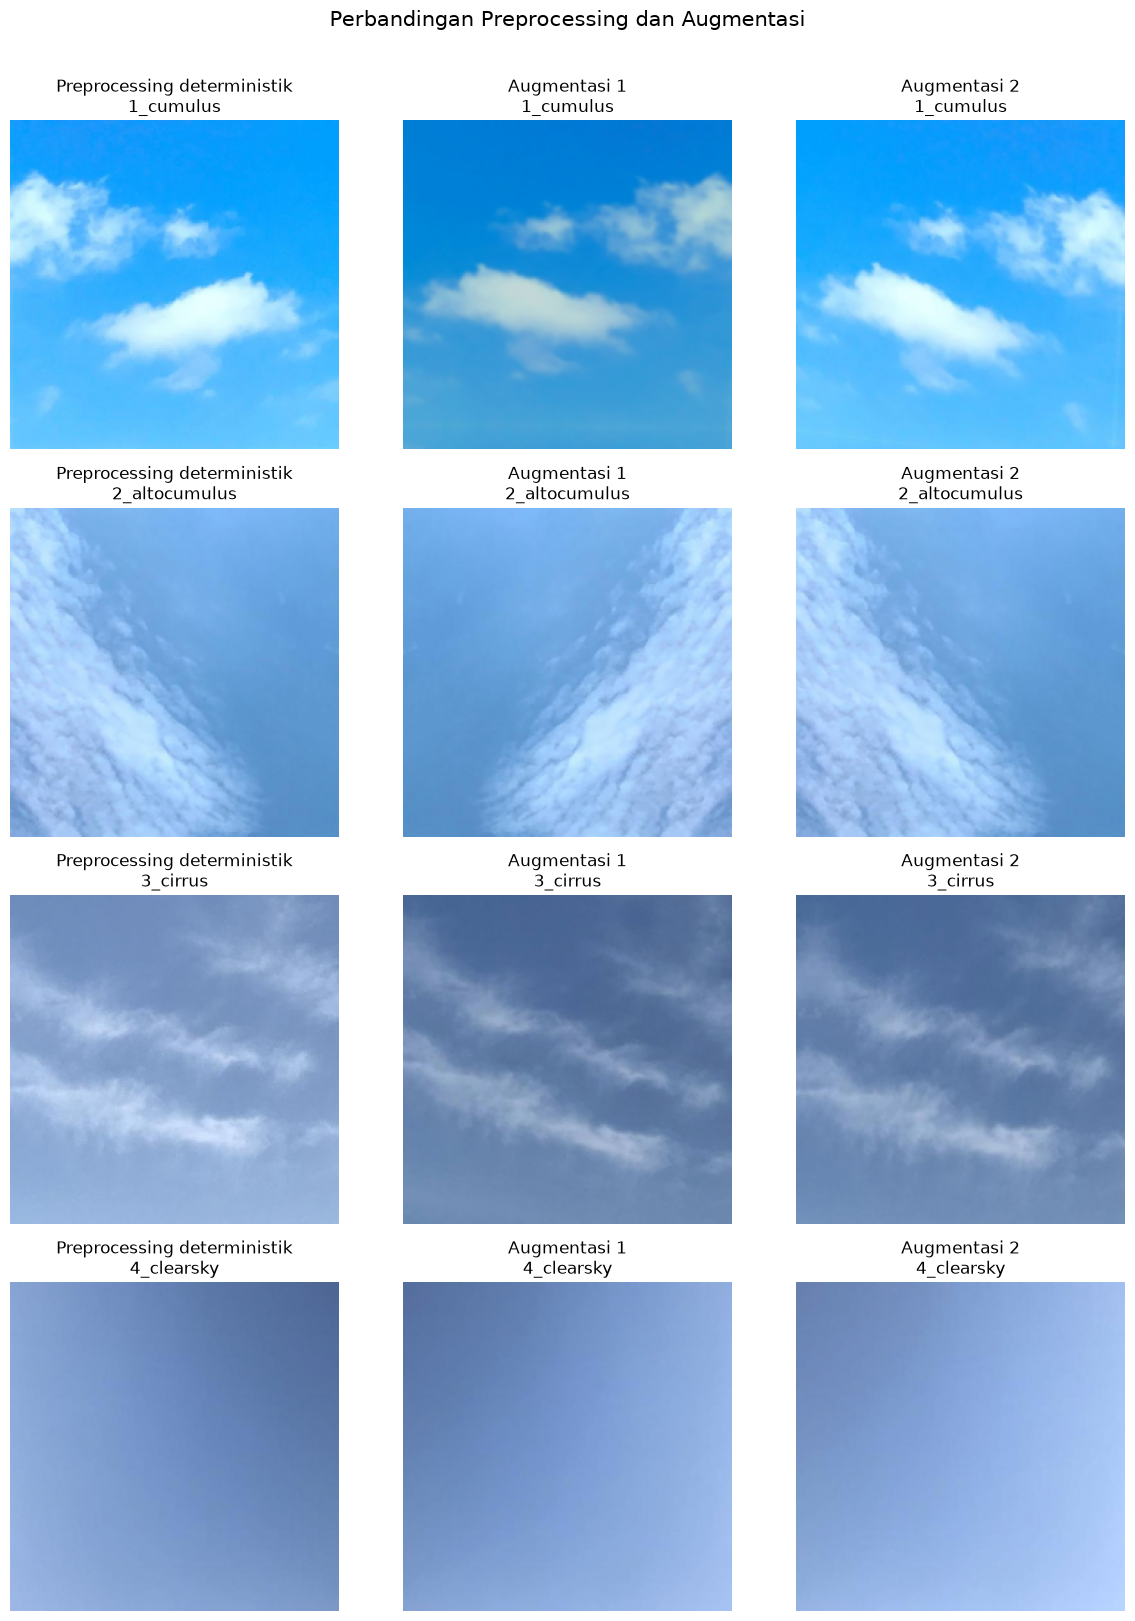

In [30]:
def tensor_to_display_image(
    image_tensor,
):
    """
    Mengembalikan tensor yang telah dinormalisasi
    menjadi citra RGB untuk visualisasi.
    """

    mean_tensor = torch.tensor(
        IMAGENET_MEAN,
        dtype=image_tensor.dtype,
    ).view(3, 1, 1)

    std_tensor = torch.tensor(
        IMAGENET_STD,
        dtype=image_tensor.dtype,
    ).view(3, 1, 1)

    restored_tensor = (
        image_tensor.cpu()
        * std_tensor
        + mean_tensor
    )

    restored_tensor = restored_tensor.clamp(
        0.0,
        1.0,
    )

    display_image = (
        restored_tensor
        .permute(1, 2, 0)
        .numpy()
    )

    return display_image


selected_rows = []

for class_index, class_name in enumerate(
    class_names[:4]
):
    class_dataframe = train_df.loc[
        train_df["class_name"].eq(
            class_name
        )
    ]

    selected_row = class_dataframe.sample(
        n=1,
        random_state=(
            RANDOM_STATE
            + class_index
        ),
    ).iloc[0]

    selected_rows.append(
        selected_row
    )


figure, axes = plt.subplots(
    nrows=len(selected_rows),
    ncols=3,
    figsize=(12, 4 * len(selected_rows)),
)


for row_index, row in enumerate(
    selected_rows
):
    original_image = read_rgb_image(
        row["file_path"]
    )

    original_tensor = (
        evaluation_transform(
            image=original_image
        )["image"]
    )

    augmentation_one = (
        train_transform(
            image=original_image
        )["image"]
    )

    augmentation_two = (
        train_transform(
            image=original_image
        )["image"]
    )

    images_to_show = [
        original_tensor,
        augmentation_one,
        augmentation_two,
    ]

    titles = [
        "Preprocessing deterministik",
        "Augmentasi 1",
        "Augmentasi 2",
    ]

    for column_index, (
        image_tensor,
        title,
    ) in enumerate(
        zip(
            images_to_show,
            titles,
        )
    ):
        axes[
            row_index,
            column_index,
        ].imshow(
            tensor_to_display_image(
                image_tensor
            )
        )

        axes[
            row_index,
            column_index,
        ].set_title(
            f"{title}\n"
            f"{row['class_name']}"
        )

        axes[
            row_index,
            column_index,
        ].axis("off")


plt.suptitle(
    "Perbandingan Preprocessing dan Augmentasi",
    fontsize=15,
    y=1.01,
)

plt.tight_layout()
plt.show()

## Pengujian Transformasi

Preprocessing validation dan test harus memberikan hasil identik ketika citra
yang sama diproses berulang kali.

Sebaliknya, pipeline training diharapkan menghasilkan variasi karena
mengandung transformasi acak.

In [31]:
validation_sample_path = (
    val_df.iloc[0]["file_path"]
)

validation_sample_image = read_rgb_image(
    validation_sample_path
)


evaluation_result_one = (
    evaluation_transform(
        image=validation_sample_image
    )["image"]
)

evaluation_result_two = (
    evaluation_transform(
        image=validation_sample_image
    )["image"]
)


evaluation_is_deterministic = torch.equal(
    evaluation_result_one,
    evaluation_result_two,
)


augmentation_variants = [
    train_transform(
        image=validation_sample_image
    )["image"]
    for _ in range(8)
]


augmentation_has_variation = any(
    not torch.equal(
        augmentation_variants[0],
        variant,
    )
    for variant in augmentation_variants[1:]
)


transform_test_df = pd.DataFrame({
    "Pemeriksaan": [
        "Evaluation bersifat deterministik",
        "Train menghasilkan variasi",
    ],
    "Status": [
        (
            "LULUS"
            if evaluation_is_deterministic
            else "GAGAL"
        ),
        (
            "LULUS"
            if augmentation_has_variation
            else "PERIKSA ULANG"
        ),
    ],
})

display(transform_test_df)


assert evaluation_is_deterministic, (
    "Transform validation/test "
    "belum deterministik."
)

,Pemeriksaan,Status
0,Evaluation bersifat deterministik,LULUS
1,Train menghasilkan variasi,LULUS


In [32]:
data_loader_generator = (
    torch.Generator()
)

data_loader_generator.manual_seed(
    RANDOM_STATE
)


train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
    worker_init_fn=seed_worker,
    generator=data_loader_generator,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
    worker_init_fn=seed_worker,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
    worker_init_fn=seed_worker,
)


loader_summary_df = pd.DataFrame({
    "DataLoader": [
        "train_loader",
        "val_loader",
        "test_loader",
    ],
    "Jumlah batch": [
        len(train_loader),
        len(val_loader),
        len(test_loader),
    ],
    "Shuffle": [
        True,
        False,
        False,
    ],
    "Batch size": [
        BATCH_SIZE,
        BATCH_SIZE,
        BATCH_SIZE,
    ],
})

display(loader_summary_df)

,DataLoader,Jumlah batch,Shuffle,Batch size
0,train_loader,247,True,32
1,val_loader,62,False,32
2,test_loader,282,False,32


In [33]:
batch_images, batch_labels = next(
    iter(train_loader)
)


expected_batch_shape = (
    batch_images.shape[0],
    3,
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
)


assert tuple(batch_images.shape) == (
    expected_batch_shape
), (
    "Bentuk batch citra tidak sesuai."
)

assert batch_images.dtype == torch.float32, (
    "Batch citra harus bertipe float32."
)

assert batch_labels.dtype == torch.int64, (
    "Label klasifikasi harus bertipe int64."
)

assert torch.isfinite(batch_images).all(), (
    "Batch citra mengandung NaN atau infinity."
)

assert batch_labels.min().item() >= 0, (
    "Ditemukan label negatif."
)

assert batch_labels.max().item() < len(
    class_names
), (
    "Ditemukan label di luar jumlah kelas."
)


print(f"Bentuk batch citra : {batch_images.shape}")
print(f"Bentuk batch label : {batch_labels.shape}")
print(f"Tipe citra         : {batch_images.dtype}")
print(f"Tipe label         : {batch_labels.dtype}")
print(f"Label minimum      : {batch_labels.min().item()}")
print(f"Label maksimum     : {batch_labels.max().item()}")

Bentuk batch citra : torch.Size([32, 3, 224, 224])
Bentuk batch label : torch.Size([32])
Tipe citra         : torch.float32
Tipe label         : torch.int64
Label minimum      : 0
Label maksimum     : 6


In [34]:
batch_images, batch_labels = next(
    iter(train_loader)
)


expected_batch_shape = (
    batch_images.shape[0],
    3,
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
)


assert tuple(batch_images.shape) == (
    expected_batch_shape
), (
    "Bentuk batch citra tidak sesuai."
)

assert batch_images.dtype == torch.float32, (
    "Batch citra harus bertipe float32."
)

assert batch_labels.dtype == torch.int64, (
    "Label klasifikasi harus bertipe int64."
)

assert torch.isfinite(batch_images).all(), (
    "Batch citra mengandung NaN atau infinity."
)

assert batch_labels.min().item() >= 0, (
    "Ditemukan label negatif."
)

assert batch_labels.max().item() < len(
    class_names
), (
    "Ditemukan label di luar jumlah kelas."
)


print(f"Bentuk batch citra : {batch_images.shape}")
print(f"Bentuk batch label : {batch_labels.shape}")
print(f"Tipe citra         : {batch_images.dtype}")
print(f"Tipe label         : {batch_labels.dtype}")
print(f"Label minimum      : {batch_labels.min().item()}")
print(f"Label maksimum     : {batch_labels.max().item()}")

Bentuk batch citra : torch.Size([32, 3, 224, 224])
Bentuk batch label : torch.Size([32])
Tipe citra         : torch.float32
Tipe label         : torch.int64
Label minimum      : 0
Label maksimum     : 6


In [35]:
preprocessing_index_df = manifest_df.loc[
    :,
    [
        "target_split",
        "class_name",
        "label",
        "target_relative_path",
        "filename",
        "width",
        "height",
        "sha256",
    ],
].copy()


split_rank = {
    split_name: split_index
    for split_index, split_name
    in enumerate(SPLIT_ORDER)
}


preprocessing_index_df[
    "_split_rank"
] = (
    preprocessing_index_df[
        "target_split"
    ].map(split_rank)
)


preprocessing_index_df = (
    preprocessing_index_df
    .sort_values(
        [
            "_split_rank",
            "class_name",
            "target_relative_path",
        ]
    )
    .drop(columns="_split_rank")
    .reset_index(drop=True)
)


assert len(preprocessing_index_df) == len(
    manifest_df
), (
    "Jumlah indeks preprocessing "
    "tidak sesuai manifest."
)

assert (
    preprocessing_index_df[
        "target_relative_path"
    ].is_unique
), (
    "Path pada indeks preprocessing "
    "harus unik."
)


display(preprocessing_index_df.head())

,target_split,class_name,label,target_relative_path,filename,width,height,sha256
0,train,1_cumulus,0,train/1_cumulus/1_cumulus_000001.jpg,1_cumulus_000001.jpg,512,512,f83d9e4fc49b398428b629595b8a8e756163da13226b4643f376b6550d956aad
1,train,1_cumulus,0,train/1_cumulus/1_cumulus_000002.jpg,1_cumulus_000002.jpg,512,512,22b272e431d325a622ed92306f2e7c5b2b32d23d3ba04db4e774f276f64f4baa
2,train,1_cumulus,0,train/1_cumulus/1_cumulus_000003.jpg,1_cumulus_000003.jpg,512,512,cb27cac01a2ed8fcdf447fae55c7ee3273341261b0ea27689b1b699ca28bc8b1
3,train,1_cumulus,0,train/1_cumulus/1_cumulus_000005.jpg,1_cumulus_000005.jpg,512,512,aab2bd3a930b7b821807daee5cf1655795adf7ddec0c59ee1d659ecd50175751
4,train,1_cumulus,0,train/1_cumulus/1_cumulus_000006.jpg,1_cumulus_000006.jpg,512,512,4386031a214e51a646b450c6b5fc1bcd8a3dbddf031802a1c0c167299e0153b5


In [36]:
class_mapping = {
    "number_of_classes": len(class_names),

    "class_names": class_names,

    "class_to_idx": class_to_idx,

    "idx_to_class": {
        str(class_index): class_name
        for class_index, class_name
        in idx_to_class.items()
    },
}


with CLASS_MAPPING_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        class_mapping,
        file,
        indent=4,
        ensure_ascii=False,
    )


print(
    "Pemetaan kelas disimpan ke:\n"
    f"{CLASS_MAPPING_PATH}"
)

Pemetaan kelas disimpan ke:
C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\processed\class_mapping.json


In [37]:
def build_split_counts(
    dataframe,
):
    """
    Membentuk jumlah citra per kelas
    untuk setiap split.
    """

    result = {}

    for split_name in SPLIT_ORDER:
        split_result = {}

        for class_name in class_names:
            count = dataframe.loc[
                dataframe[
                    "target_split"
                ].eq(split_name)
                &
                dataframe[
                    "class_name"
                ].eq(class_name)
            ].shape[0]

            split_result[class_name] = int(
                count
            )

        result[split_name] = split_result

    return result


preprocessing_config = {
    "project": "cloud-classification",

    "dataset": "Ground-based Cloud Dataset",

    "source_manifest": (
        MANIFEST_PATH.name
    ),

    "random_state": RANDOM_STATE,

    "image_size": {
        "height": IMAGE_HEIGHT,
        "width": IMAGE_WIDTH,
        "channels": 3,
    },

    "normalization": {
        "name": "ImageNet",
        "mean": list(IMAGENET_MEAN),
        "std": list(IMAGENET_STD),
        "max_pixel_value": 255.0,
    },

    "train_augmentation": {
        "on_the_fly": True,

        "horizontal_flip": {
            "probability": 0.50,
        },

        "affine": {
            "probability": 0.50,
            "scale": [0.90, 1.10],
            "translate_percent": [
                -0.05,
                0.05,
            ],
            "rotate_degree": [
                -10,
                10,
            ],
            "shear_degree": [
                -3,
                3,
            ],
        },

        "brightness_contrast": {
            "probability": 0.35,
            "brightness_limit": 0.15,
            "contrast_limit": 0.15,
        },

        "gaussian_blur": {
            "probability": 0.10,
            "blur_limit": [3, 5],
        },
    },

    "validation_augmentation": False,
    "test_augmentation": False,

    "data_loader": {
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
        "train_shuffle": True,
        "validation_shuffle": False,
        "test_shuffle": False,
    },

    "number_of_classes": len(
        class_names
    ),

    "class_to_idx": class_to_idx,

    "dataset_counts": (
        build_split_counts(
            manifest_df
        )
    ),

    "library_versions": {
        "python": sys.version.split()[0],
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "torch": torch.__version__,
        "opencv": cv2.__version__,
        "albumentations": A.__version__,
    },
}


with PREPROCESSING_CONFIG_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        preprocessing_config,
        file,
        indent=4,
        ensure_ascii=False,
    )


print(
    "Konfigurasi preprocessing disimpan ke:\n"
    f"{PREPROCESSING_CONFIG_PATH}"
)

Konfigurasi preprocessing disimpan ke:
C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\processed\preprocessing_config.json


In [38]:
preprocessing_index_df.to_csv(
    PREPROCESSING_INDEX_PATH,
    index=False,
    encoding="utf-8",
)


print(
    "Indeks preprocessing disimpan ke:\n"
    f"{PREPROCESSING_INDEX_PATH}"
)

Indeks preprocessing disimpan ke:
C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\processed\preprocessing_dataset_index.csv


In [39]:
output_files = [
    PREPROCESSING_INDEX_PATH,
    CLASS_MAPPING_PATH,
    PREPROCESSING_CONFIG_PATH,
]


output_table = pd.DataFrame({
    "File": output_files,
    "Ada": [
        path.is_file()
        for path in output_files
    ],
    "Ukuran (KB)": [
        (
            path.stat().st_size / 1024
            if path.is_file()
            else np.nan
        )
        for path in output_files
    ],
})


output_table["File"] = (
    output_table["File"].map(
        lambda path: path.relative_to(
            PROJECT_DIR
        )
    )
)

display(output_table)

,File,Ada,Ukuran (KB)
0,dataset\processed\preprocessing_dataset_index.csv,True,2954.967773
1,dataset\processed\class_mapping.json,True,0.662109
2,dataset\processed\preprocessing_config.json,True,2.909180


In [40]:
saved_index_df = pd.read_csv(
    PREPROCESSING_INDEX_PATH
)

with CLASS_MAPPING_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    saved_class_mapping = json.load(
        file
    )

with PREPROCESSING_CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    saved_preprocessing_config = (
        json.load(file)
    )


assert len(saved_index_df) == len(
    manifest_df
), (
    "Indeks yang disimpan tidak lengkap."
)

assert (
    saved_class_mapping[
        "class_to_idx"
    ]
    == class_to_idx
), (
    "Pemetaan kelas berubah setelah disimpan."
)

assert (
    saved_preprocessing_config[
        "image_size"
    ]["height"]
    == IMAGE_HEIGHT
), (
    "Tinggi citra pada konfigurasi tidak sesuai."
)

assert (
    saved_preprocessing_config[
        "image_size"
    ]["width"]
    == IMAGE_WIDTH
), (
    "Lebar citra pada konfigurasi tidak sesuai."
)


print(
    "Seluruh metadata berhasil "
    "dimuat ulang dan divalidasi."
)

Seluruh metadata berhasil dimuat ulang dan divalidasi.


In [41]:
final_checks = {
    "Manifest tersedia dan tidak kosong": (
        MANIFEST_PATH.is_file()
        and not manifest_df.empty
    ),

    "Jumlah kelas sesuai GCD": (
        len(class_names)
        == EXPECTED_CLASS_COUNT
    ),

    "Seluruh file citra tersedia": (
        missing_image_df.empty
    ),

    "Seluruh kelas tersedia pada setiap split": (
        class_coverage_ok.all()
    ),

    "Label dimulai dari nol": (
        manifest_df["label"].min()
        == 0
    ),

    "Label sesuai jumlah kelas": (
        manifest_df["label"].max()
        == len(class_names) - 1
    ),

    "Ukuran tensor sesuai konfigurasi": (
        tuple(sample_tensor.shape)
        == (
            3,
            IMAGE_HEIGHT,
            IMAGE_WIDTH,
        )
    ),

    "Tensor bertipe float32": (
        sample_tensor.dtype
        == torch.float32
    ),

    "Batch tidak mengandung NaN": (
        torch.isfinite(
            batch_images
        ).all().item()
    ),

    "Validation dan test deterministik": (
        evaluation_is_deterministic
    ),

    "Augmentasi hanya digunakan pada train": (
        train_dataset.transform
        is train_transform
        and val_dataset.transform
        is evaluation_transform
        and test_dataset.transform
        is evaluation_transform
    ),

    "Jumlah dataset sesuai manifest": (
        (
            len(train_dataset)
            + len(val_dataset)
            + len(test_dataset)
        )
        == len(manifest_df)
    ),

    "Indeks preprocessing tersimpan": (
        PREPROCESSING_INDEX_PATH.is_file()
    ),

    "Pemetaan kelas tersimpan": (
        CLASS_MAPPING_PATH.is_file()
    ),

    "Konfigurasi preprocessing tersimpan": (
        PREPROCESSING_CONFIG_PATH.is_file()
    ),
}


final_check_df = pd.DataFrame({
    "Pemeriksaan": final_checks.keys(),

    "Status": [
        "LULUS" if passed else "GAGAL"
        for passed in final_checks.values()
    ],
})

display(final_check_df)

,Pemeriksaan,Status
0,Manifest tersedia dan tidak kosong,LULUS
1,Jumlah kelas sesuai GCD,LULUS
2,Seluruh file citra tersedia,LULUS
3,Seluruh kelas tersedia pada setiap split,LULUS
4,Label dimulai dari nol,LULUS
5,Label sesuai jumlah kelas,LULUS
6,Ukuran tensor sesuai konfigurasi,LULUS
7,Tensor bertipe float32,LULUS
8,Batch tidak mengandung NaN,LULUS
9,Validation dan test deterministik,LULUS


In [42]:
failed_checks = [
    check_name
    for check_name, passed
    in final_checks.items()
    if not passed
]


if failed_checks:
    formatted_checks = "\n".join(
        f"- {check_name}"
        for check_name in failed_checks
    )

    raise RuntimeError(
        "Preprocessing belum lolos "
        "seluruh pemeriksaan:\n"
        f"{formatted_checks}"
    )


print("=" * 72)
print("TAHAP 05 SELESAI")
print(
    "Pipeline preprocessing dan augmentasi "
    "siap digunakan untuk training."
)
print("=" * 72)

TAHAP 05 SELESAI
Pipeline preprocessing dan augmentasi siap digunakan untuk training.


## Kesimpulan

Notebook `05_preprocessing_augmentasi.ipynb` telah menghasilkan pipeline input
untuk klasifikasi citra awan dengan ketentuan berikut:

- ukuran input citra adalah `224 × 224` piksel;
- seluruh citra dikonversi menjadi RGB tiga kanal;
- normalisasi menggunakan mean dan standard deviation ImageNet;
- augmentasi hanya diterapkan pada data training;
- validation dan test menggunakan preprocessing deterministik;
- augmentasi dilakukan secara on-the-fly;
- tidak ada citra hasil augmentasi yang disimpan secara fisik;
- tidak ada perubahan pada `dataset/raw`;
- tidak ada perubahan pada `dataset/source`;
- label kelas dibuat secara konsisten dari 0 sampai 6;
- Dataset dan DataLoader PyTorch telah diuji;
- bentuk tensor adalah `[batch_size, 3, 224, 224]`;
- metadata preprocessing telah disimpan pada `dataset/processed`.

Metadata yang dihasilkan:

```text
dataset/processed/
├── preprocessing_dataset_index.csv
├── class_mapping.json
└── preprocessing_config.json

## Menyimpan Pipeline Transform

Pipeline preprocessing dan augmentasi disimpan dalam format JSON agar dapat digunakan
kembali oleh notebook DataLoader, training, evaluasi, dan prediksi tanpa mendefinisikan
transform yang sama berulang kali.